###  **Candidate number:** [Add here!]

# Assignment 3 (summative)

##  --------- Part 1 ---------

In this assignment you will use the Openweathermap Current Whether Data API to access weather information for cities in the UK. You need to sign up for an account with Openweathermap to get a Key. You will get 1,000 API calls per day for free. https://openweathermap.org/api

#### Q1. Get a list of all cities in the UK (excluding Crown Dependencies and Overseas Territories). (15 points)
Hint: To get the name of all cities in UK, consider scraping this website https://www.gov.uk/government/publications/list-of-cities/list-of-cities-html.

In [432]:
from bs4 import BeautifulSoup
import requests

url = 'https://www.gov.uk/government/publications/list-of-cities/list-of-cities-html'

page = requests.get(url)
soup = BeautifulSoup(page.content,'lxml')

# Larger section where cities are located in html
content = soup.find('div', class_='govspeak').find_all(['h3', 'ul'])

# Creates empty list object to store cities
cities = []

# Loop over headings and lists in the order they appear
for elm in content:

    # Extracting and cleaning text from each element
    txt = elm.get_text(" ", strip=True).replace('*', '') 

    # Stop the loop once we reach crown dependencies section
    if elm.name == 'h3' and txt == 'Crown Dependencies':
        break
    
    # Skip other section headings
    if elm.name == 'h3':
        continue
    
    # Extracting the list of cities from ul element in html
    if elm.name == 'ul':
        for li in elm.find_all('li'):
            city = li.get_text(" ", strip=True).replace('*', '')
            cities.append(city) # Add city to list

print(cities)


['Bath', 'Birmingham', 'Bradford', 'Brighton & Hove', 'Bristol', 'Cambridge', 'Canterbury', 'Carlisle', 'Chelmsford', 'Chester', 'Chichester', 'Colchester', 'Coventry', 'Derby', 'Doncaster', 'Durham', 'Ely', 'Exeter', 'Gloucester', 'Hereford', 'Kingston-upon-Hull', 'Lancaster', 'Leeds', 'Leicester', 'Lichfield', 'Lincoln', 'Liverpool', 'London', 'Manchester', 'Milton Keynes', 'Newcastle-upon-Tyne', 'Norwich', 'Nottingham', 'Oxford', 'Peterborough', 'Plymouth', 'Portsmouth', 'Preston', 'Ripon', 'Salford', 'Salisbury', 'Sheffield', 'Southampton', 'Southend-on-Sea', 'St Albans', 'Stoke on Trent', 'Sunderland', 'Truro', 'Wakefield', 'Wells', 'Westminster', 'Winchester', 'Wolverhampton', 'Worcester', 'York', 'Armagh', 'Bangor', 'Belfast', 'Lisburn', 'Londonderry', 'Newry', 'Aberdeen', 'Dundee', 'Dunfermline', 'Edinburgh', 'Glasgow', 'Inverness', 'Perth', 'Stirling', 'Bangor', 'Cardiff', 'Newport', 'St Asaph', 'St Davids', 'Swansea', 'Wrexham']


#### Q2. Use the Openweathermap Current Whether Data API to access the following information for each city: **main.temp, wind.speed, rain (1h) and Time of data calculation (dt)**. Use default units for these variables. Add the city name, temperature, wind, rain and dt information to a DataFrame as separate columns. If one of these attributes is missing, replace it with NONE. (25 points)
Hint: You may find it easier to create a dictionary with cities as keys and temperature, wind, rain and date as values first and then convert it into a DataFrame.

In [458]:
import pandas as pd 
import requests

api_key = 'd1c4d63338d855c771c38809c76332af'

# Initalize empty list for weather
weather_ls = []

for city in cities: 

    # Covers each city in iteration for weather
    query = f"q={city},GB"

    res=requests.get('http://api.openweathermap.org/data/2.5/weather?'+query+'&APPID='+api_key)
    data = res.json()

    temp = data.get("main", {}).get("temp")
    wind = data.get("wind", {}).get("speed")
    rain = data.get("rain", {}).get("1h")
    dt   = data.get("dt")

    # Adds the specified data stored as dictionary into weather list
    weather_ls.append({
        "city": city,
        "temp": temp,
        "wind": wind,
        "rain_1h": rain,
        "dt": dt
    })

# Turns list to dataframe and replaces nan values with None
df_weather = pd.DataFrame(weather_ls)
df_weather = df_weather.fillna('None')
print(df_weather)


               city    temp  wind rain_1h            dt
0              Bath   279.9  2.94    None  1763326119.0
1        Birmingham  278.19  3.09    None  1763326362.0
2          Bradford  277.34   3.6    None  1763326387.0
3   Brighton & Hove  279.42  0.89    None  1763326411.0
4           Bristol  279.91  4.63    None  1763326169.0
..              ...     ...   ...     ...           ...
71          Newport  280.25  4.96    None  1763326384.0
72         St Asaph  280.39  0.45    None  1763326337.0
73        St Davids  281.53  8.56    None  1763326415.0
74          Swansea  280.73  1.34    None  1763326299.0
75          Wrexham  278.88  2.28    None  1763326415.0

[76 rows x 5 columns]


#### Q3. The Time of data calculation (dt) is in Unix Timestamp format. Convert it to standard UTC (``dd/mm/yy @ HH:MM:SS``). Print out the updated DataFrame. (5 points)
Hint: You may use ``datetime.fromtimestamp`` to convert dt.

In [459]:
from datetime import datetime

# Convert Unix Timestamp to standard UTC
df_weather["dt"] = df_weather["dt"].apply(
    lambda x: datetime.fromtimestamp(int(x)).strftime("%d/%m/%y @ %H:%M:%S")
    if (pd.notna(x) and x != "None")
    else None
)

print(df_weather)


               city    temp  wind rain_1h                   dt
0              Bath   279.9  2.94    None  16/11/25 @ 20:48:39
1        Birmingham  278.19  3.09    None  16/11/25 @ 20:52:42
2          Bradford  277.34   3.6    None  16/11/25 @ 20:53:07
3   Brighton & Hove  279.42  0.89    None  16/11/25 @ 20:53:31
4           Bristol  279.91  4.63    None  16/11/25 @ 20:49:29
..              ...     ...   ...     ...                  ...
71          Newport  280.25  4.96    None  16/11/25 @ 20:53:04
72         St Asaph  280.39  0.45    None  16/11/25 @ 20:52:17
73        St Davids  281.53  8.56    None  16/11/25 @ 20:53:35
74          Swansea  280.73  1.34    None  16/11/25 @ 20:51:39
75          Wrexham  278.88  2.28    None  16/11/25 @ 20:53:35

[76 rows x 5 columns]


#### Q4. The default temperature units in Openweathermap are Kelvin. Convert it to Celsius. Print out the DataFrame. (5 points)
Hint: You may use the API to access the temperature in Celsius or use the convertion formula to convert the Kelvin values in your DataFrame. 

In [461]:
df_weather["temp"] = df_weather["temp"].apply(
    lambda x: x - 273.15 if (pd.notna(x) and x != "None") else None
)

df_weather.head()

,city,temp,wind,rain_1h,dt
0,Bath,6.75,2.94,None,16/11/25 @ 20:48:39
1,Birmingham,5.04,3.09,None,16/11/25 @ 20:52:42
2,Bradford,4.19,3.6,None,16/11/25 @ 20:53:07
3,Brighton & Hove,6.27,0.89,None,16/11/25 @ 20:53:31
4,Bristol,6.76,4.63,None,16/11/25 @ 20:49:29


## --------- Part 2 ---------


In this assignment you will explore climate data for South East and Central South England from the MetOffice: <a href="https://www.metoffice.gov.uk/pub/data/weather/uk/climate/datasets/Tmean/date/England_SE_and_Central_S.txt">link</a>. 

**Please make sure all your plots have appropriate axes labels, titles, and legends (if applicable)!**

In [462]:
import pandas as pd
import requests
from io import StringIO

url = 'https://www.metoffice.gov.uk/pub/data/weather/uk/climate/datasets/Tmean/date/England_SE_and_Central_S.txt'

text = requests.get(url).text
lines = text.splitlines()

header_index = next(i for i, line in enumerate(lines) if "year" in line.lower())

df = pd.read_csv(
    StringIO("\n".join(lines[header_index:])),
    delim_whitespace=True
)

df.rename(columns={df.columns[0]: "Year"}, inplace=True)
df.set_index("Year", inplace=True)

display(df.head())


/var/folders/yg/zl_mj9293nl6lf_m2lkl24wc0000gn/T/ipykernel_65316/93691525.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec,win,spr,sum,aut,ann
Year,,,,,,,,,,,,,,,,,
1884,6.1,5.4,6.4,6.9,11.6,14.0,16.3,17.4,14.9,9.2,5.4,4.7,---,8.30,15.93,9.80,9.87
1885,2.5,6.1,4.6,8.0,9.3,14.4,16.6,14.6,12.7,7.6,6.0,3.3,4.36,7.28,15.22,8.75,8.81
1886,2.0,0.9,3.8,7.9,10.9,13.8,16.2,16.1,14.4,11.4,6.4,2.4,2.09,7.53,15.38,10.75,8.90
1887,1.6,3.4,3.6,6.3,9.7,15.0,17.4,16.1,12.0,7.0,4.7,2.8,2.46,6.55,16.16,7.89,8.33
1888,2.6,1.2,3.5,6.0,10.5,13.5,14.0,14.5,13.1,7.7,8.1,4.9,2.22,6.66,14.02,9.61,8.32


#### Q2. Plot the line plots for monthly averages.

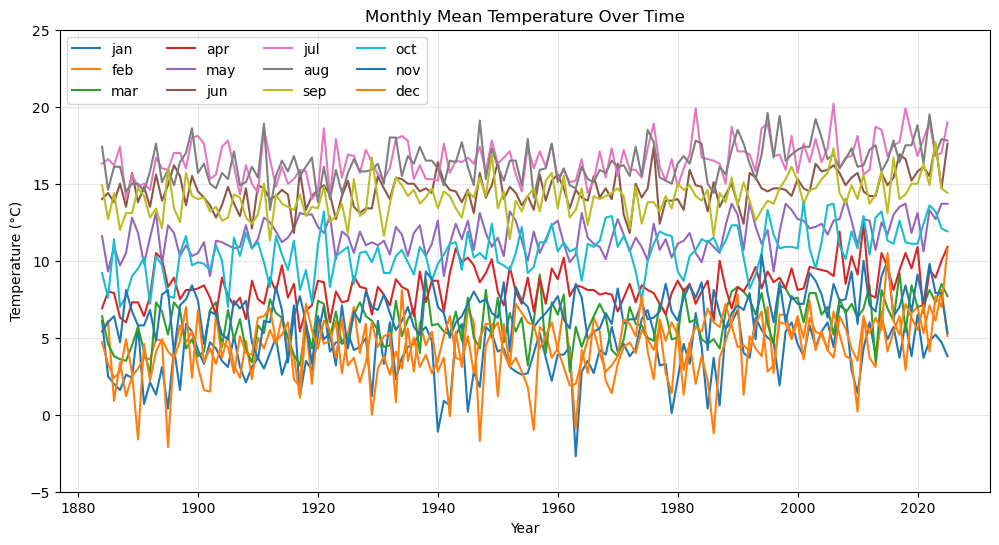

In [463]:
import matplotlib.pyplot as plt

# Extract first 12 columns for months
months = df.columns[:12]

# Plotting the data with trend lines

plt.figure(figsize=(12, 6))

# For each month, we plot its line
for m in months:
    plt.plot(df.index, df[m], label=m)


# Add formatting and labels to graph
plt.title("Monthly Mean Temperature Over Time")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")

# Y axis limits so legend formats well into graph
plt.ylim(-5, 25)
plt.legend(ncol=4, loc="upper left")
plt.grid(alpha=0.3)
plt.show()

#### Q3. Plot the monthly average box plots (with months on the x-axis and temperature on the y-axis).

/var/folders/yg/zl_mj9293nl6lf_m2lkl24wc0000gn/T/ipykernel_65316/3850314846.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[m] for m in months], labels=months)


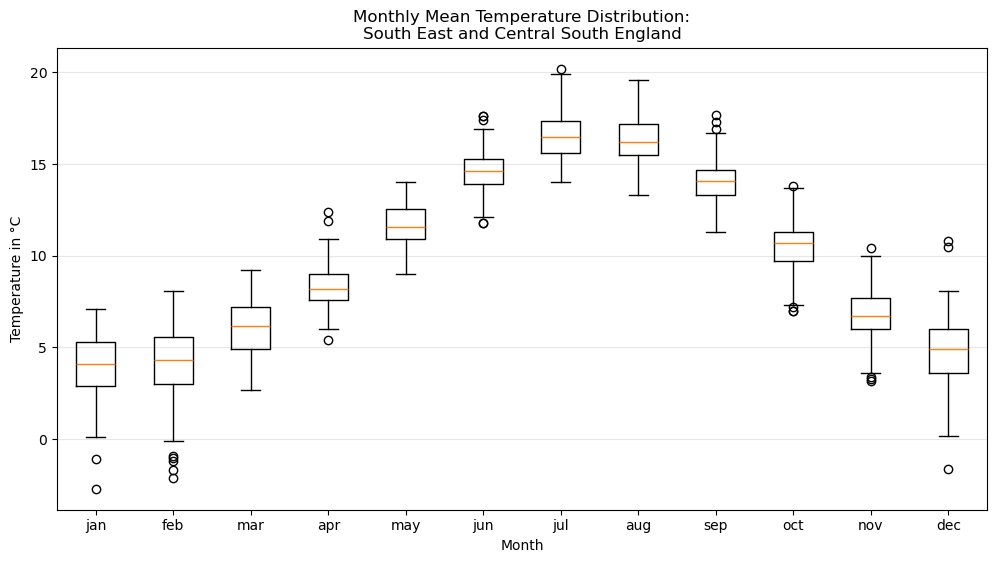

In [464]:
plt.figure(figsize=(12, 6))

# Boxplot expects the data as a list of arrays (one per month)
plt.boxplot([df[m] for m in months], labels=months)

plt.title("Monthly Mean Temperature Distribution:\nSouth East and Central South England")
plt.xlabel("Month")
plt.ylabel("Temperature in °C")
plt.grid(axis="y", alpha=0.3)

plt.show()

#### Q4. Plot the histograms of annual temperatures for all years until and including 1970 and all years after 1970.

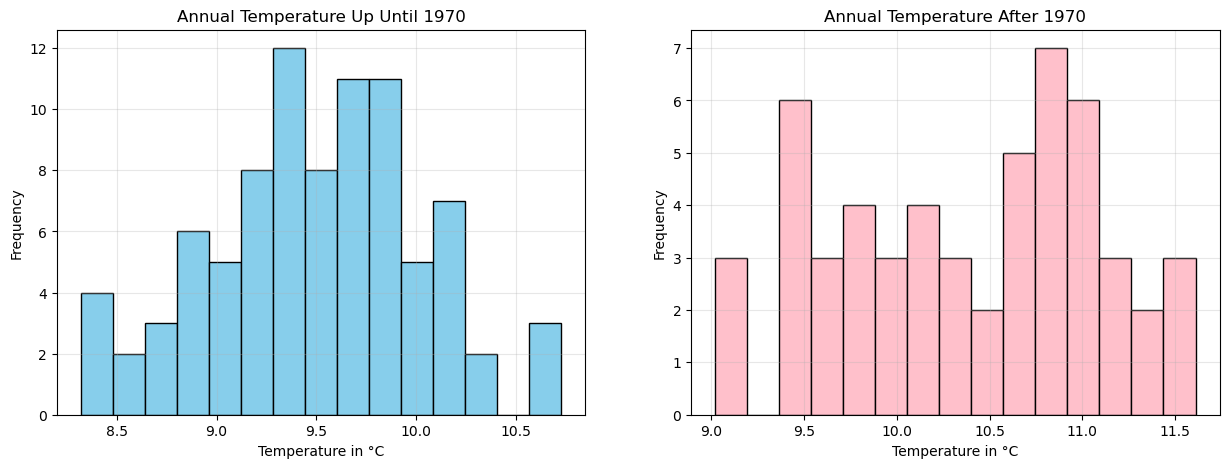

In [465]:
annual_temp = df["ann"]

# Same axis 

#Two groups split by years
before_1970 = annual_temp[annual_temp.index <= 1970]
after_1970 = annual_temp[annual_temp.index > 1970]

plt.figure(figsize=(15,5))

# Plotting histogram 1 - up until 1970
plt.subplot(1,2,1)
plt.hist(before_1970.dropna(), bins = 15, color = 'skyblue', edgecolor = 'black')
plt.title("Annual Temperature Up Until 1970")
plt.xlabel("Temperature in °C")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

# Plotting histogram 2 - after 1970
plt.subplot(1,2,2)
plt.hist(after_1970.dropna(), bins = 15, color = 'pink', edgecolor = 'black')
plt.title("Annual Temperature After 1970")
plt.xlabel("Temperature in °C")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.show()


#### Q5. What hypothesis could be raised based on the figure in Q4?

Hypothesis: The average annual temperature in South East and Central London has increased after 1970 compared to the decades prior. 

#### Q6. Calculate a 10-year rolling mean for the annual temperature and plot it in the same plot as the original annual data.
Hint: You may use pandas ``rolling`` function.

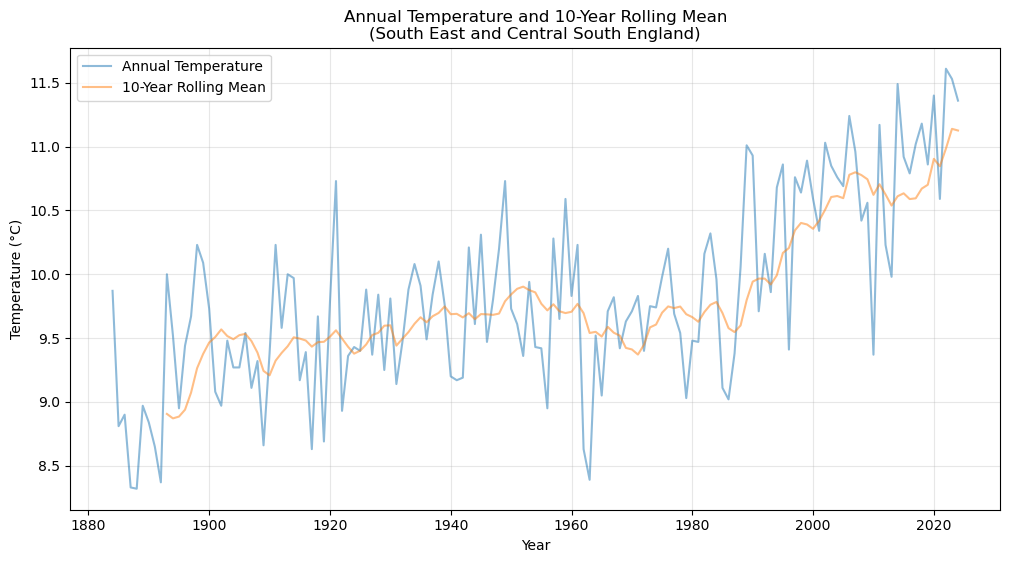

In [466]:
rolling_ten = annual_temp.rolling(window=10).mean()

plt.figure(figsize=(12, 6))

plt.plot(df.index, annual_temp, label="Annual Temperature", alpha=0.5)

plt.plot(df.index, rolling_ten, label="10-Year Rolling Mean", alpha=0.5)

plt.title("Annual Temperature and 10-Year Rolling Mean\n(South East and Central South England)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


#### Q7. Plot the <a href="https://en.wikipedia.org/wiki/Warming_stripes">warming stripes</a> using annual temperature. Use ``sns.heatmap`` with ``cmap="coolwarm"`` as colour map. Make the stripes vertical (for example, by transposing the data).

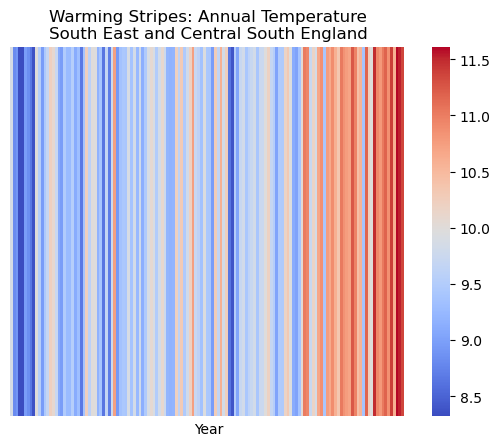

In [467]:
import seaborn as sns

stripes = pd.DataFrame(annual_temp).T 

plt.Figure(figsize=(15,2))

sns.heatmap(
    stripes,
    cmap="coolwarm",
    xticklabels=False,
    yticklabels=False
)

plt.title("Warming Stripes: Annual Temperature\nSouth East and Central South England")
plt.show()

#### Q8. Calculate the average annual temperature with respect to the mean of 1961-1990 and plot as warming stripes (as in Q7). 
You may want to create a separate attribute in your DataFrame called Anomaly that contains the difference between annual temperatures for each year and the mean annual temperature for the reference years, 1961-1990.

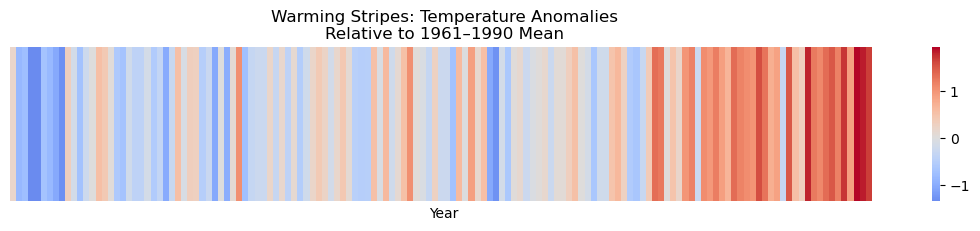

In [468]:
ref_yrs_mean = annual_temp.loc[1961:1990].mean()

df["Anomaly"] = annual_temp - ref_yrs_mean

stripe_anomaly = pd.DataFrame(df["Anomaly"]).T
plt.figure(figsize=(14,2))

sns.heatmap(
    stripe_anomaly,
    cmap="coolwarm",
    center=0,
    xticklabels=False,
    yticklabels=False
)

plt.title("Warming Stripes: Temperature Anomalies\nRelative to 1961–1990 Mean")
plt.show()



#### Q9. Plot the warming stripes for the 10-year rolling mean from Q6 with respect to the mean of 1961-1990.
As in Q8, you may want to add an attribute to your DataFrame for 10yr_Rolling_Mean_Anomaly that includes the difference between the rolling mean and the mean for the reference years.

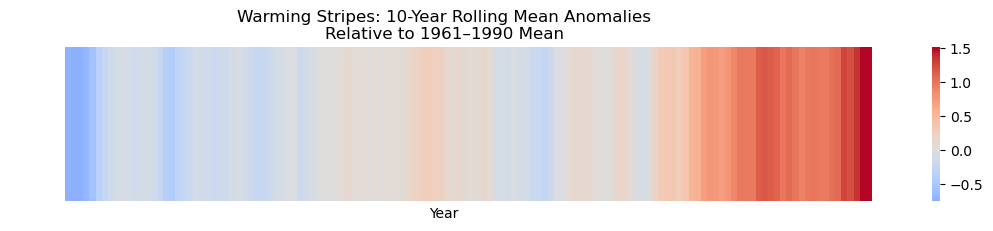

In [469]:
ref_yrs_mean_roll = rolling_ten.loc[1961:1990].mean()

df["Rolling10_Anomaly"] = rolling_ten - ref_yrs_mean_roll

stripe_roll_anom = pd.DataFrame(df["Rolling10_Anomaly"]).T
plt.figure(figsize=(14, 2))

sns.heatmap(
    stripe_roll_anom,
    cmap="coolwarm",
    center=0,
    xticklabels=False,
    yticklabels=False
)

plt.title("Warming Stripes: 10-Year Rolling Mean Anomalies\nRelative to 1961–1990 Mean")
plt.show()